# D7 — Accurate coefficients, stored digits, and input sensitivity

This notebook audits the isolated axial moment operator from D6. The experiment does not evolve a Navier-Stokes flow or evaluate an admissible full-profile perturbation.

In [1]:
import json
import numpy as np
from IPython.display import Image, display
from nscomp.moments import SmoothBump
from nscomp.conditioning import (axial_system,stable_axial_solve,high_precision_solve,
    coefficient_relative_error,reference_moment_remainder)
from nscomp.d7 import STUDY, WRITING, load_parameters, generate
p=load_parameters()
bumps=[SmoothBump(c,p['halfwidth']) for c in p['centers']]
d=np.array(p['d_u'])
lam=p['precision_scan']['lambda']

## Compare coefficients with an independent reference

The stable formulation evaluates the nearly coincident row difference using expm1. Its right-hand side is transformed too. The reference integrates the original continuous bump weights at 70 decimal digits.

In [2]:
matrix,reference=high_precision_solve(lam,p['centers'],p['halfwidth'],d,p['reference_digits'])
raw=np.linalg.solve(axial_system(lam,bumps,p['quadrature_order']),-d)
stable=stable_axial_solve(lam,bumps,d,p['quadrature_order'])
print('Raw coefficient relative error:',coefficient_relative_error(raw,reference))
print('Stable coefficient relative error:',coefficient_relative_error(stable,reference))
print('Original moment remainder after float64 storage:',reference_moment_remainder(matrix,stable,d))

Raw coefficient relative error: 0.00018642319405954487
Stable coefficient relative error: 6.454998881227127e-17
Original moment remainder after float64 storage: 0.00030517578124921054


## Keep the computed digits

A high-precision solve only helps the final cancellation if later operations retain the required digits. Here we compare the original moments using both retained coefficients and coefficients rounded back to float64.

In [3]:
for digits in p['precision_scan']['digits']:
    _,values=high_precision_solve(lam,p['centers'],p['halfwidth'],d,digits)
    retained=reference_moment_remainder(matrix,values,d)
    rounded=reference_moment_remainder(matrix,[float(v) for v in values],d)
    print(f'{digits} digits: retained remainder={retained:.3g}; float64 storage={rounded:.3g}')

20 digits: retained remainder=1.89e-09; float64 storage=0.000305


30 digits: retained remainder=3.9e-19; float64 storage=0.000305
40 digits: retained remainder=1.94e-31; float64 storage=0.000305


50 digits: retained remainder=5.64e-39; float64 storage=0.000305


## Perturb supplied data separately

Use the near-compatible discrepancy (1,1) at lambda=1e-10, changing only its second component. The mathematical and support constraints of this two-moment experiment remain satisfied. Full-profile admissibility is not evaluated.

In [4]:
s=p['sensitivity']
base=np.array(s['base_discrepancies'])
a0=stable_axial_solve(s['lambda'],bumps,base)
for eps in s['perturbations']:
    changed=base+np.array([0.,eps])
    a1=stable_axial_solve(s['lambda'],bumps,changed)
    relative_input=np.linalg.norm(changed-base)/np.linalg.norm(base)
    relative_output=np.linalg.norm(a1-a0)/np.linalg.norm(a0)
    print(f'Input change={relative_input:.3g}; coefficient change={relative_output:.3g}; ratio={relative_output/relative_input:.3g}')

Input change=7.07e-15; coefficient change=5.04e-05; ratio=7.13e+09
Input change=7.07e-13; coefficient change=0.00504; ratio=7.13e+09
Input change=7.07e-11; coefficient change=0.504; ratio=7.13e+09
Input change=7.07e-09; coefficient change=50.4; ratio=7.13e+09
Input change=7.07e-07; coefficient change=5.04e+03; ratio=7.13e+09


## Regenerate the three experiments

The CSV data keep original moment errors, coefficient errors, failed-solve status, precision settings, and the actual represented perturbations separate.

In [5]:
summary=generate()
print(json.dumps(summary,indent=2))

{
  "reference_digits": 70,
  "largest_stable_coefficient_relative_error": 4.810002379309584e-16,
  "raw_singular_lambda_values": [
    1e-18
  ],
  "selected_lambda": 1e-12,
  "selected_raw_coefficient_error": 0.00018642319405954487,
  "selected_stable_coefficient_error": 6.454998881227127e-17,
  "selected_stable_original_moment_remainder": 0.00030517578124921054,
  "sensitivity_amplification_range": [
    7129318346.785803,
    7129318346.789186
  ],
  "classification": "educational numerical-analysis note; no novel research claim",
  "dynamical_stability": false,
  "parameters_sha256": "e7d2a4d324e4a7a5d346f1031b97875bd3b78f4ccc3355dca059c50145f74ecf"
}


## Figures and research classification

The result is an educational numerical-analysis note. It does not establish a new blowup or stability result. The research decision lists the additional profile and error-analysis evidence needed for a manuscript.

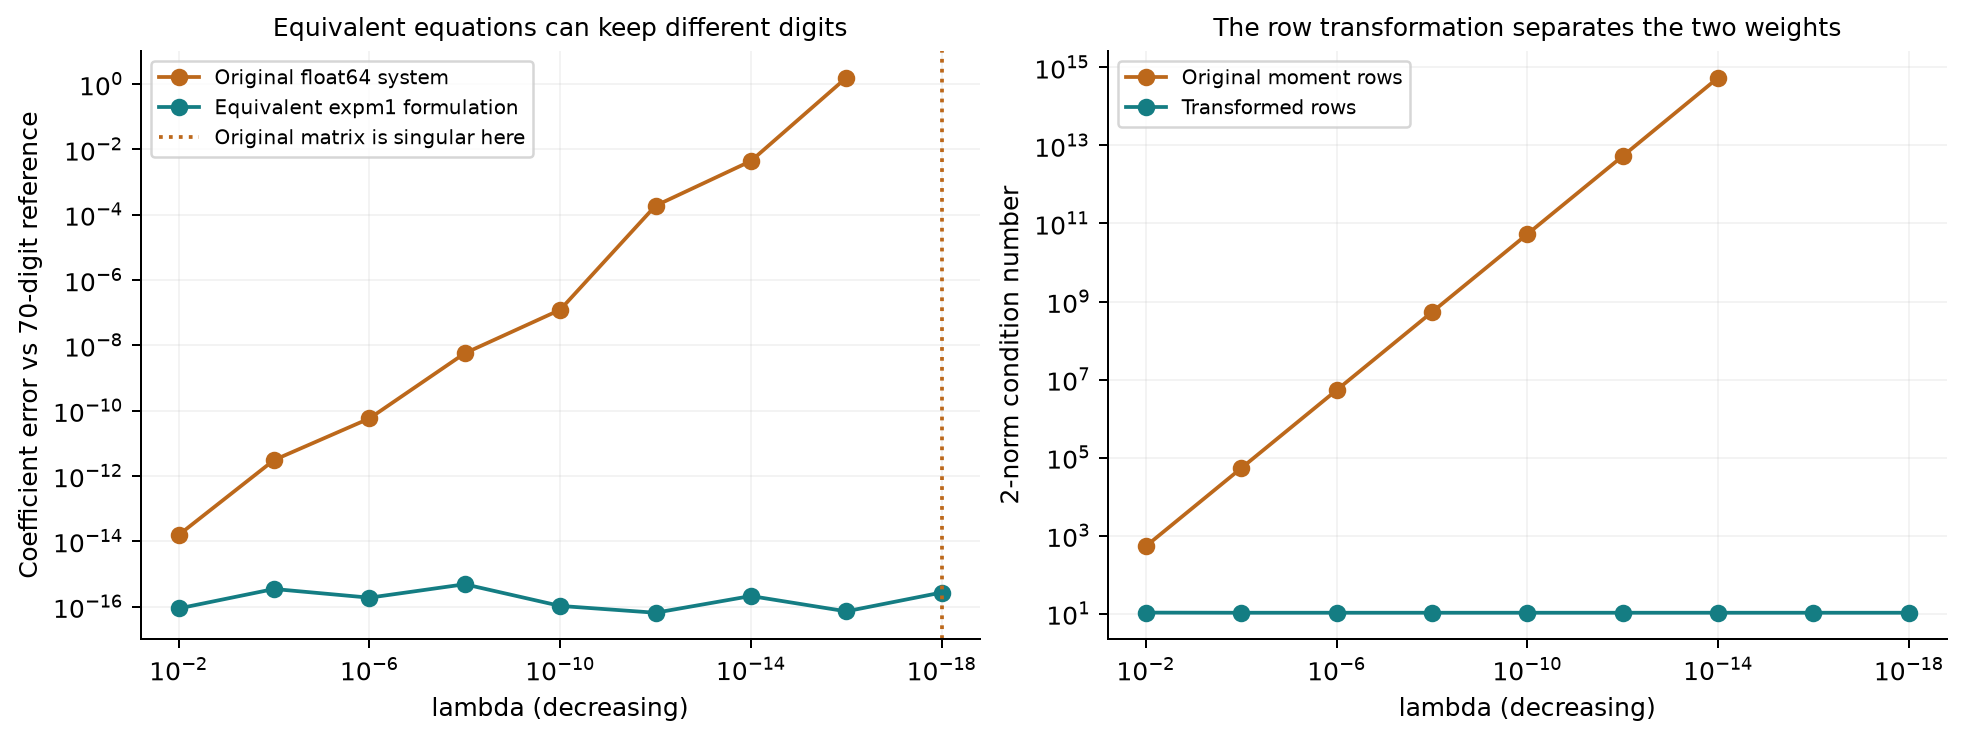

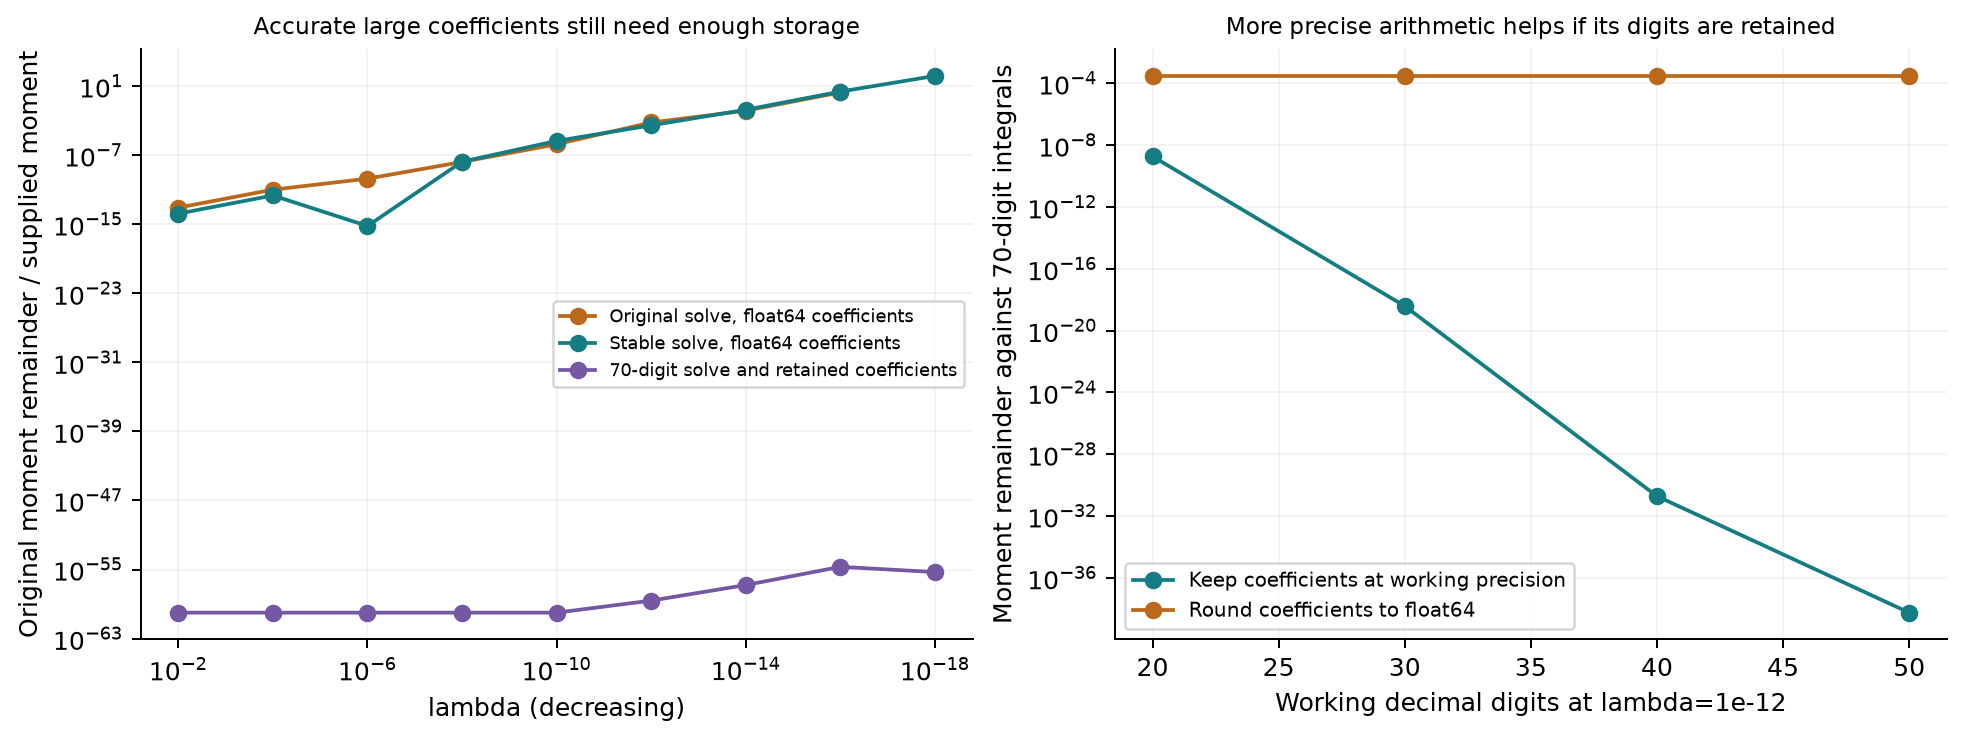

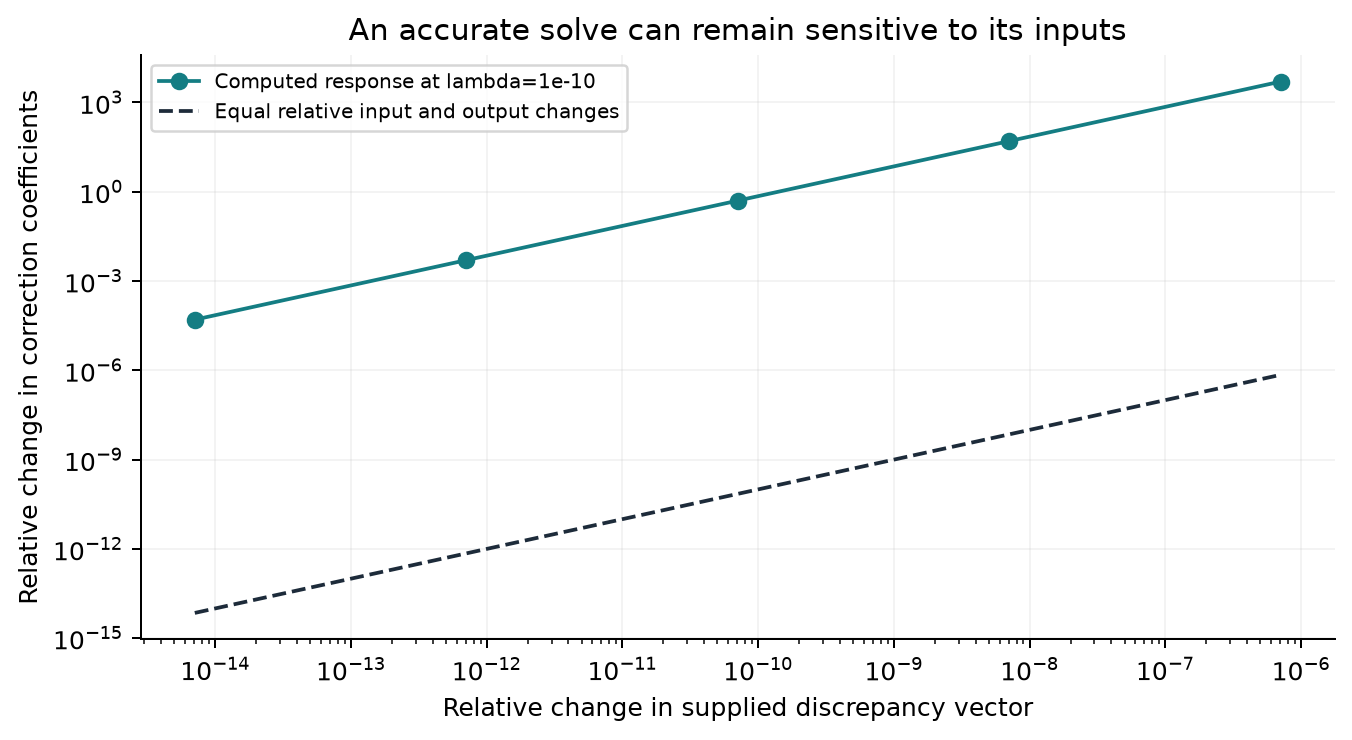

In [6]:
for name in ('01_equivalent_formulations','02_precision_and_storage','03_input_sensitivity'):
    display(Image(filename=str(WRITING/'figures'/f'{name}.png')))